# Homework 6

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
from tqdm import tqdm
from functools import cache
from typing import Union, Callable
import traceback

In [18]:
import numpy as np
from typing import Union

In [19]:
# %%save_block code/plot_stress_strain.py

def plot_stress_strain(
    pointnames,
    stresses, 
    strains, 
    segment_colors = ['g', 'orange', 'b', 'purple'],
    labels = None,
    arrow_density=20,
    NPLOT=1,
    pointoffsetx=-0.005,
    pointoffsety=0.1,
    stressunit='kPa',
    nxticks=10,
    nyticks=10,
    mutation_scale=30):
    
    refdx = np.max(strains) - np.min(strains)
    refdy = np.max(stresses) - np.min(stresses)

    for i in range(len(strains)-1):
        
        x1, x2 = strains[i:i+2]
        y1, y2 = stresses[i:i+2]
        
        # Get the number of arrows to plot and normalize x/y directions to unit square
        seg_len = np.sqrt(((y2 - y1)/refdy)**2 + ((x2 - x1)/refdx)**2)
        n_arrows = int(arrow_density*seg_len + 0.5)
        
        # slope values for arrows
        dx = (x2 - x1)/(n_arrows+2)
        dy = (y2 - y1)/(n_arrows+2)
        if dx == 0 or dy == 0: continue
        
        # point locations for arrows
        xs = np.arange(min(x1,x2)+abs(dx/2), max(x1,x2)-abs(dx/2), abs(dx))
        ys = np.arange(min(y1,y2)+abs(dy/2), max(y1,y2)-abs(dx/2), abs(dy))
        
        # Plot the line segment for P1 -> P2
        
        tag = '' if labels is None else f'({labels[i]})'
        plt.plot(
            [x1,x2], 
            [y1,y2], 
            color=segment_colors[i], )
            # label=fr'${pointnames[i]}\rightarrow {pointnames[i+1]}$ {tag}')
        
        # Draw in some nice arrows
        for (x,y) in zip(xs,ys):
            xy = (x+dx/2, y+dy/2)
            xytext = (x, y)

            plt.annotate("", xy=xy, xytext=xytext,
                arrowprops=dict(
                    arrowstyle="->", 
                    mutation_scale=mutation_scale,
                    color=segment_colors[i], 
                    alpha=0.7,),)
    
    # Put some labels for the points on the plot to make it more descriptive
    for i, (name, stress, strain) in enumerate(zip(pointnames, stresses, strains)):
        plt.text(
            strain + pointoffsetx, 
            stress + pointoffsety,
            name,
            backgroundcolor=(1,1,1,0.2),
            )
        plt.scatter([strain],[stress],s=40,color='k')
    
    # 
    plt.axhline(0, color='k', linewidth=0.75)
    plt.axvline(0, color='k', linewidth=0.75)
    
    xticks = np.linspace(np.min(strains), np.max(strains), nxticks)
    yticks = np.linspace(np.min(stresses), np.max(stresses), nyticks)
    
    plt.xticks(xticks, rotation=45)
    plt.yticks(yticks)
    
    leny = refdy/20/2
    lenx = refdx/20/2
    plt.vlines(xticks, -leny, leny, linewidth=0.5, color='k')
    plt.hlines(yticks, -lenx, lenx, linewidth=0.5, color='k')
    
    plt.xlim([np.min(strains)-refdx/10, np.max(strains)+refdx/10])
    plt.ylim([np.min(stresses)-refdy/10, np.max(stresses)+refdy/10])

    plt.ylabel(rf'$\sigma$({stressunit})')
    plt.xlabel(r'$\epsilon$')
    plt.title(fr' Plot {NPLOT}: $\sigma$ vs. $\epsilon$')
        
    plt.legend()# bbox_to_anchor=(1,1),loc='upper left');

In [20]:
## %%save_block ./code/const_model.py

calc_yield_stress = lambda sign, alpha, kappa: alpha + kappa*np.sign(sign)
calc_yield_f = lambda stress, alpha, kappa: np.abs(stress - alpha) - kappa
calc_Eep = lambda E, H_kappa, H_alpha: E*(H_kappa + H_alpha)/(E + H_kappa + H_alpha)

def check_if_elastic(direction, stress, alpha, kappa, stepfactor=1e-8):
    yield_stress = calc_yield_stress(direction, alpha, kappa)
    step = np.sign(direction)*stepfactor
    yield_f = calc_yield_f(stress + step,  alpha, kappa)
    
    return yield_f < 0

def calc_Etangent(is_elastic, E, H_kappa, H_alpha):
    if is_elastic: return E
    else: return calc_Eep(E, H_kappa, H_alpha)

calc_dstrain = lambda dstress, Etangent: dstress/Etangent

calc_dgamma_elastic = lambda dstrain, stress, E, H_kappa, H_alpha: 0
calc_dgamma_hardening = lambda dstrain, stress, E, H_kappa, H_alpha: E*dstrain*np.sign(stress)/(E + H_alpha + H_kappa)

def calc_dgamma(is_elastic, dstrain, stress, E,H_kappa, H_alpha):
    if is_elastic: return calc_dgamma_elastic(dstrain, stress, E, H_kappa, H_alpha)
    else: return calc_dgamma_hardening(dstrain, stress, E, H_kappa, H_alpha)

calc_dalpha = lambda dgamma, stress, alpha, H_alpha: H_alpha*np.sign(stress - alpha)*dgamma
calc_dkappa = lambda dgamma, H_kappa: H_kappa*dgamma

In [21]:
# %%save_block ./code/stress_path.py

point_name = lambda i : bytes.decode((int.from_bytes(str.encode('A'))+(i-1)).to_bytes())  if i > 0 else 'O'

def doprint(n, pointA, pointB, is_elastic,  stress, next_stress, strain, Etangent, kappa, alpha, dstress, dstrain, dgamma, dkappa, dalpha):
    out = f'n={n}\n{pointA}->{pointB}\nis elastic?={is_elastic}\nstress={stress:.3e}\nnextstress={next_stress:.3e}\nstrain={strain:.3e}\nEtangent={Etangent:.3e}\nkappa={kappa:.3e}\nalpha={alpha:.3e}\n' \
        f'dstress={dstress:.3e}\ndstrain={dstrain:.3e}\ndgamma={dgamma:.3e}\ndkappa={dkappa:.3e}\ndalpha={dalpha:.3e}\n'
    print(out)
    
def solve_stress_path_analytic(E, H_kappa, H_alpha, alpha0, kappa0, stresses,  verbose=False, tol=1e-8, stepfactor=1e-8):
    stress = 0
    strain = 0
    alpha = alpha0
    kappa = kappa0
    next_stress = stresses[0]
    n = 0
    
    POINTNAMES = []
    STRESS = []
    STRAIN = []
    ALPHA = []
    KAPPA = []
    
    def doappend(pointname, stress, strain, alpha, kappa):
        POINTNAMES.append(pointname)
        STRESS.append(stress)
        STRAIN.append(strain)
        ALPHA.append(alpha)
        KAPPA.append(kappa)
        
    pointname = point_name(n)
        
    doappend(pointname, stress, strain, alpha, kappa)
    while n < len(stresses):
        
        next_stress = stresses[n]
        
        if abs(stress - next_stress) < tol: 
            stress = next_stress
            n += 1
            continue
        
        direction = np.sign(next_stress - stress)
        is_elastic = check_if_elastic(direction, stress, alpha, kappa, stepfactor=stepfactor)
        
        if is_elastic:
            yield_stress = calc_yield_stress(direction, alpha, kappa)
            dstress = direction*min(abs(yield_stress - stress), abs(next_stress - stress))
            
            if np.sign(direction) < 0:
                stress = max(yield_stress, next_stress)
            elif np.sign(direction) > 0:
                stress = min(yield_stress, next_stress)
            
        else:
            n += 1
            dstress = next_stress - stress
            stress = next_stress
            
        Etangent = calc_Etangent(is_elastic, E, H_kappa, H_alpha)
        dstrain = calc_dstrain(dstress, Etangent)
        dgamma = calc_dgamma(is_elastic, dstrain, stress, E, H_kappa, H_alpha)
        dkappa = calc_dkappa(dgamma, H_kappa)
        dalpha = calc_dalpha(dgamma, stress, alpha, H_alpha)
        
        strain += dstrain 
        kappa += dkappa
        alpha += dalpha
        
        if verbose: 
            next_stress = stresses[n]
            doprint(n,pointname, point_name(len(POINTNAMES)), is_elastic, stress, next_stress, strain, Etangent, kappa, alpha, dstress, dstrain, dgamma, dkappa, dalpha)
        
        pointname = point_name(len(POINTNAMES))
        doappend(pointname, stress, strain, alpha, kappa)
        
    return POINTNAMES, STRESS, STRAIN, KAPPA, ALPHA

In [22]:
def ramp_func(Fsteps, tparts, interpolation='Cosine'):

    assert len(tparts)+1 == len(Fsteps)
    t_end = np.sum(tparts)


    tparts = np.concatenate(([0], tparts))
    tsteps = np.cumsum(tparts)

    def F(t):
        for i, (ti, Fi) in enumerate(zip(tsteps[1:], Fsteps[1:])):
            if t <= ti: break
            
        j = i
        tj = tsteps[j]
        Fj = Fsteps[j]
        
        dt = ti - tj
        dF = Fi - Fj
        
        if interpolation == 'Cosine':
            f = dF*(1 - np.cos(np.pi*(t - tj)/dt))/2 + Fj
        elif interpolation == 'Linear':
            f = dF/dt*(t - tj) + Fj
                
        return f
    
    return F, tsteps, t_end

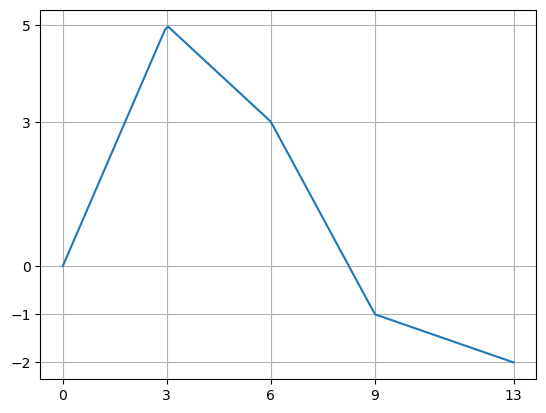

In [23]:
nsteps = 150

t_end = 1


Fsteps = [0,5,3,-1,-2]
Fparts = [3,3,3,4]

F, tsteps, t_end = ramp_func(Fsteps, Fparts, 'Linear')
dt = t_end/nsteps

n = np.arange(0,t_end+dt,dt)
plt.plot(n, [F(ni) for ni in n])

plt.yticks(Fsteps)
plt.xticks(tsteps)
plt.grid()

In [24]:
from IPython.core.magic import register_cell_magic
@register_cell_magic
def save_block(line, cell):
    """ Run and save a python code block to a file.

    Args:
        line (_type_): _description_
        cell (_type_): _description_
    """
    with open(line, 'wt') as fd:
        fd.write(cell)
    code = compile(cell, line, 'exec')
    exec(code, globals())

In [25]:
@cache
def calc_GuassPoints(numips:int):
    """ Calculate the Guass-Legendre Quadrature points and weights 
    for a specified number of integration points.
    See: https://en.wikipedia.org/wiki/Gaussian_quadrature

    Args:
        numips (int): Number of integration points

    Returns:
        (points (np.array), weights (np.array)): the points and weights for numips
    """
    
    x = np.zeros(numips) # locations
    w = np.zeros(numips) # weights
    
    # Get Nth order Legendre Polynomial
    n = np.zeros(numips+1)
    n[-1] = 1
    Pn = np.polynomial.legendre.Legendre(n)
    x = Pn.roots()
    w = 2/(1-x**2)/(Pn.deriv()(x))**2
    
    return x, w

def calc_xe(xi, x1e, x2e):
    return (x2e - x1e)*0.5*(xi + 1) + x1e

def calc_xi(x1e, x2e, x):
    denom = x2e - x1e
    numer = 2*(x - 0.5*(x2e +x1e))
    return numer/denom

def calc_dxi_dx(x1e, x2e, x):
    denom = x2e - x1e
    return 2/denom
    
def calc_element_nodes(Nen):
    return np.linspace(-1,1,Nen)

def ensure_dim_2d(x:np.array):
    x = np.asarray(x).astype(float)
    x = np.atleast_2d(x)
    if x.shape[1] != 1:
        x = x.T
    return x
    
def calc_N(Nen:int, xi:Union[np.array,float]):
    """ Calculate the finite element shape function

    Args:
        Nen (int): number of element nodes
        xi (np.ndarray | float): value(s) to evaluate at

    Returns:
        np.array: the finite element shape function
    """
    
    XI = calc_element_nodes(Nen)
    xi = ensure_dim_2d(xi)
    N = np.empty((Nen, xi.shape[0]))
    for i in range(Nen):
        denom = numer = 1
        for j in range(Nen):
            if j == i: continue
            denom *= XI[i] - XI[j]
            numer *= xi - XI[j]
        N[i] = np.squeeze(numer / denom)
    return np.array(N)

def calc_B(Nen:int, xi:Union[np.ndarray,float]):
    """ Calculate the derivative of the finite element shape function

    Args:
        Nen (int): number of element nodes
        xi (np.ndarray | float): _description_

    Returns:
        np.array: the derivative of the finite element shape function
    """
    
    XI = calc_element_nodes(Nen)
    xi = ensure_dim_2d(xi)
    B = np.empty((Nen, xi.shape[0]))
    for i in range(Nen):
        numer = 0
        denom = 1
        for j in range(Nen):
            if j == i: continue
            numer_j = 1 + np.zeros_like(xi)
            denom *= XI[i] - XI[j]
            for k in range(Nen):
                if k == i or k == j: continue
                numer_j *= xi - XI[k]
                
            numer += numer_j
        B[i] = np.squeeze(numer/denom)

    return np.array(B)

In [26]:
def calc_stress(strain, B, stress_sat):
    return (B*stress_sat)*strain

def calc_dstress_dstrain(strain, B, stress_sat):
    return B*stress_sat

In [27]:
default_stress = lambda strain: np.nan
default_dstress_dstrain = lambda strain : np.nan

def calc_el_force_f(
    calc_el_f,
    Neldof,
    numips:int,
    j:float,)->np.array:
    """ Calculate element external force vector

    Args:
        f_dist (np.array): element distributed force
        numips (int): number of integration points
        j (float): jacobian
        A (float): cross-sectional area

    Returns:
        np.array: the element externa l force vector
    """
    
    # Get Guass points and loop through
    xis, weights = calc_GuassPoints(numips)
    N = calc_N(Neldof, xis)
    el_f = calc_el_f(xis)
    f_f = np.sum((el_f*weights*N),axis=1, keepdims=True)*j
    return f_f

def calc_el_force_int(
    el_stress:np.array,
    Neldof:int,
    numips:int, 
    j:float,
    A:float,
    )->np.array:
    """ Calculate element internal force vector

    Args:
        displ (np.array): element displacements
        numips (int): number of integration points
        j (float): jacobian
        A (float): cross-sectional area
        calc_stress (Callable[[float],float], optional): Calculate the stress from strain.

    Returns:
        np.array: the element internal force vector
    """
    
    xis, weights = calc_GuassPoints(numips)
    B = calc_B(Neldof, xis)/j
    f_e = np.sum(weights*el_stress*B, axis=1, keepdims=True)*A*j
    return f_e
        
def calc_el_consist_tang(
    el_dstress_dstrain,
    Neldof:int,
    numips:int, 
    j:float,
    A:float,)->np.array:
    """ Calculate element consistent tangent

    Args:
        displ (np.array): Element displacement
        numips (int): number of Guassian quadrature integration points
        j (float): transformation jacobian
        A (float): cross-sectional area
        calc_dstress_dstrain (Callable[[float],float], optional): Calculate derivative of stress against strain.

    Returns:
        np.array: element consistent tangent
    """
    
    # Calculate jacobian
    
    xis, weights = calc_GuassPoints(numips)
    B = calc_B(Neldof, xis)/j
    k_e = (el_dstress_dstrain*weights*B)@B.T*A*j
    return k_e


In [28]:
def calc_el_stress_ep( 
    Neldof,
    numips:int, 
    j:float,
    el_stress_n,
    el_strain_n,
    el_Ddispl,
    el_isvs_n,
    params)->float:
    """ Calculate the element stress

    Args:
        displ (np.array): element displacements
        numips (int): number of guass quadrature integration points
        j (float): transformation jacobian
        A (float): cross-sectional area
        calc_stress (Callable[[float],float], optional): Calculate stress from strain.

    Returns:
        float: The element stress
    """

    nisvs = 3

    el_strain = np.zeros((numips,  1))
    el_stress = np.zeros((numips, 1))
    el_isvs = np.zeros((numips, nisvs))
    el_dstress_dstrain = np.zeros((numips, 1))

    E, H_kappa, H_alpha = params
    
    xi_vect, weights = calc_GuassPoints(numips)
    for i, (xi, wi, strain_ni, stress_ni, isvs_ni) in enumerate(zip(xi_vect, weights, el_strain_n, el_stress_n, el_isvs_n)):
        B = calc_B(Neldof, xi)/j
        dstrain =  B.T@el_Ddispl
        
        trial_stress = stress_ni + E*dstrain
        el_strain[i] = strain_ni + dstrain
        
        alpha_n, kappa_n, gamma_n = isvs_ni
        
        # print('kappa =', kappa, 'alpha =', alpha, 'zeta =', zeta)
       
        f_trial_yield = np.abs(trial_stress - alpha_n) - kappa_n
        if (f_trial_yield > 0):
            dgamma = f_trial_yield/(E + H_alpha + H_kappa)
            dalpha = H_alpha*dgamma*np.sign(trial_stress - alpha_n)
            dkappa = H_kappa*dgamma
            dstress = -E*dgamma*np.sign(trial_stress - alpha_n)
            el_isvs[i, 0] = alpha_n + dalpha
            el_isvs[i, 1] = kappa_n + dkappa
            el_isvs[i, 2] = gamma_n + dgamma
            el_stress[i] = trial_stress + dstress
            el_dstress_dstrain[i] = E*(H_kappa + H_alpha)/(E + H_kappa + H_alpha)
        else:
            el_stress[i] = trial_stress
            el_isvs[i] = el_isvs_n[i]
            el_dstress_dstrain[i] = E
    
    return el_strain, el_stress, el_isvs, el_dstress_dstrain

In [29]:
def mesh_bar(L, Nel):
    lcoords, el_length = np.linspace(0,L,Nel+1,retstep=True)
    rcoords = lcoords + el_length
    lcoords, rcoords
    coords = np.array([lcoords,rcoords]).T[:-1]
    return coords, el_length

def calc_coords(Nel:int, Neldof:int, a:float, b:float)->dict:
    """ Calculate the node coordinates, element coordinates, and transformation jacobian.

    Args:
        Nel (int): Number of elements
        Neldof (int): Number of element degrees of freedom
        a (float): left boundary location
        b (float): right boundary location

    Returns:
        np.array, float, np.array: (coords, jacobian, node_coords)
    """
    
    Nnodes = calc_Nnodes(Nel, Neldof)
    
    node_coords, dx = np.linspace(a, b, Nnodes, retstep=True)
    jac = dx/2
    coords = np.zeros((Nel, Neldof))
    
    node = 0
    for i in range(Nel):
        for j in range(Neldof):
            coords[i,j] = node_coords[node]
            node += 1
            
        else: node -= 1
        
    return coords,  jac, node_coords

def calc_Nnodes(Nel:int, Neldof:int)->int:
    """ Calculate the number of nodes in a 1D bar

    Args:
        Nel (int): Number of elements
        Neldof (int): Number of element degrees of freedom

    Returns:
        int: Number of nodes
    """
    return Nel*(Neldof - 1) + 1

def calc_LM(Nel:int, Neldof:int, fixed_bcs:np.ndarray=None):
    """ Construct the location matrix for FEM assembly.

    Args:
        Nel (int): Number of elements
        Neldof (int): Number of element nodes
        F_g (np.ndarray): Prescribed fixed boundary conditions

    Returns:
        (np.array, int): The location matrix and number of degrees of freedom.
    """
    
    calc_full = fixed_bcs is None
    
    Nnodes = calc_Nnodes(Nel, Neldof)
    if not fixed_bcs is None: assert len(fixed_bcs) == Nnodes
    
    LM = np.zeros((Nel, Neldof), dtype=int)
    
    dof = 0
    node = 0
    for i in range(Nel):
        for j in range(Neldof):
            node += 1
            if not calc_full and not np.isnan(fixed_bcs[node-1]): 
                continue
            dof += 1
            LM[i,j] = dof
            
        node -= 1
        dof -= 1
        
    else: dof += 1
    
    return LM, dof

eldefault = lambda el: None   
idefault = lambda el,i,I: None
ijdefault = lambda el,i,I,j,J : None             

def Assemble_I(Nel, LM, elop=eldefault, ndofop=idefault, dofop=idefault):
    for el in range(Nel):
        el_dof_loc = LM[el,:]
        elop(el)
        for i, I in enumerate(el_dof_loc):
            if I == 0: ndofop(el, i,I)
            else: dofop(el, i, I)

def Assemble_IJ(Nel, LM, elop=eldefault, ndofop=ijdefault, dofop=ijdefault):
    for el in range(Nel):
        el_dof_loc = LM[el,:]
        elop(el)
        for i, I in enumerate(el_dof_loc):
            for j, J in enumerate(el_dof_loc):
                if I == 0 or J == 0: ndofop(el,i,I,j,J)
                else: dofop(el, i,I,j,J)
                
def Assemble_F_f( LM, Nel, Neldof, Ndof, numips, calc_f, coords:np.array, jac:float):
    
    F_f_el = np.zeros((Nel, Neldof, 1))
    F_f = np.zeros((Ndof, 1))
    
    def elop(el):
        
        el_coords = coords[el]
        x1e, x2e = el_coords[0], el_coords[-1]
        xe = lambda xi: calc_xe(xi, x1e, x2e)
        el_f = lambda xi : calc_f(xe(xi))
        
        F_f_el[el, :, :] = calc_el_force_f(el_f, Neldof, numips, jac)
    
    def dofop(el,i,I):
        F_f[I-1, :] = F_f_el[el, i]
    
    Assemble_I(Nel, LM, elop=elop, dofop=dofop)
    return F_f

def Assemble_F_int(
    LM:np.arange, 
    Nel:int, 
    Neldof:int, 
    Ndof:int, 
    numips:int,
    stress:np.array,
    jac:float,
    A:float)->np.array:
    
    f_int_el = np.zeros((Nel,Neldof,1))
    F_int = np.zeros((Ndof, 1))
    
    def elop(el):
        el_stress = stress[el]
        f_int_el[el,:,:] = calc_el_force_int(el_stress, Neldof, numips, jac, A)
        
    def dofop(el, i, I):
        F_int[I-1, :] += f_int_el[el, i]
        
    Assemble_I(Nel, LM, elop=elop, dofop=dofop)
    
    return F_int

def Assemble_dF_int_dd(
    LM:np.array, 
    Nel:int, 
    Neldof:int, 
    Ndof:int, 
    Nnodes:int,
    numips:int,
    dstress_dstrain:np.array, 
    jac, 
    A,
    full_LM=None,)->np.array:
    
    df_int_dd_el = np.zeros((Nel, Neldof, Neldof))
    dF_int_dd = np.zeros((Ndof, Ndof))
    if full_LM is not None:
        ndof_dF_int_dd = np.zeros((Ndof, Nnodes))
    
    def elop(el):
        el_dstress_dstrain = dstress_dstrain[el]
        df_int_dd_el[el,:,:] = calc_el_consist_tang(el_dstress_dstrain, Neldof, numips, jac, A)
    
    def dofop(el, i, I, j, J):
        dF_int_dd[I-1,J-1] += df_int_dd_el[el,i,j]
    
    def ndofop(el, i, I, j, J):
        if J == 0 and I != 0:
            Ip = full_LM[el, i]
            Jp = full_LM[el, j]
            ndof_dF_int_dd[I-1,Jp-1] += df_int_dd_el[el,i,j]
        
    Assemble_IJ(Nel,LM, elop=elop, dofop=dofop, ndofop=ijdefault if full_LM is None else ndofop)
    
    if full_LM is None:
        return dF_int_dd
    else:
        return dF_int_dd, ndof_dF_int_dd

In [53]:
def FE_code_displ(
    A=3e-4, # m2
    L= 0.15, #m
    f = 3.0, #N/m 
    numips = 1,
    Nel = 2,
    Neldof=2,
    rtol=1e-10, 
    atol=1e-8, 
    maxiter=10,
    t_end=1.0,
    calc_F_conc_vector=None,
    calc_fixed_bcs=None,
    el_isvs_0 =None,
    nsteps=None,
    nisvs=None,
    calc_el_stress=None,
    cons_params=None,
    ):

    dt = t_end/nsteps

    # full_LM, Nnodes = calc_LM(Nel, Neldof)
    full_LM, Nnodes = calc_LM(Nel, Neldof)
    fixed_displ = calc_fixed_bcs(Nnodes, 0)
    fixed_ddispl = np.zeros_like(fixed_displ)
    LM, Ndof = calc_LM(Nel, Neldof, fixed_displ)

    coords, jac, node_coords = calc_coords(Nel, Neldof, 0, L)

    calc_f_dist = lambda n, x : f + 0*x


    # Initialize sotrage for displacments/veloc/accel
    # Allow for setting ISVs using a single value or a list for each element
    displ = np.zeros((Ndof, 1))
    displ_n = displ.copy()
    full_displ = np.zeros((Nnodes, 1))

    el_isvs = el_isvs_0.copy()
    el_isvs = np.stack([el_isvs]*numips, axis=1)
    el_isvs_n = el_isvs.copy()

    el_strain = np.zeros((Nel, numips, 1))
    el_strain_n = el_strain.copy()
    el_stress = np.zeros((Nel, numips, 1))
    el_stress_n = el_stress.copy()
    el_displ = np.zeros((Nel, Neldof, 1))
    el_Ddispl = np.zeros((Nel, Neldof, 1))
    el_dstress_dstrain    = np.zeros((Nel, numips, 1))

    # veloc = np.zeros((Ndof, 1))
    # accel = np.zeros((Ndof, 1))
    
    TIME = np.arange(0,t_end+dt,dt)
    NN = np.arange(nsteps+1)
    DISPL = np.zeros((nsteps+1, Nnodes, 1))
    
    # VELOC = np.zeros((nsteps+1, Ndof, 1))
    # ACCEL = np.zeros((nsteps+1, Ndof, 1))
    ISVS  = np.zeros((nsteps+1, Nel, numips, nisvs))
    ISVS[0] = el_isvs
    STRAIN = np.zeros((nsteps+1, Nel, numips, 1))
    STRESS = np.zeros((nsteps+1, Nel, numips, 1))
    DSTRESS_DSTRAIN =   np.zeros((nsteps+1, Nel, numips, 1))
    FORCE           = np.zeros((nsteps+1, Nnodes, 1))
    
     # Start of pseudo-time loop
    t = 0.0

    with tqdm(total=nsteps, position=0) as pbar:
        try:
            for n in range(1, nsteps+1):

                t = TIME[n]
                F_F = calc_F_conc_vector(Ndof, t)
                # Element distribute, d force vectors

                Rtol = 1

                new_fixed_displ = calc_fixed_bcs(Nnodes, t)
                fixed_ddispl = new_fixed_displ - fixed_displ
                fixed_displ = new_fixed_displ

                displ_n = displ.copy()
                el_isvs_n = el_isvs.copy()
                el_strain_n = el_strain.copy()
                el_stress_n = el_stress.copy()

                # [0, np.nan, np.nan, np.nan, np.nan, 1]

                # store nodal displacements from time step n
                # Start of iteration loop
                for k in range(maxiter):
                    if (Rtol < rtol): break

                    if (k == 0):
                        ddispl = np.zeros((Ndof,1))
                    else:
                        ddispl = np.linalg.solve(dR_dd, -R)

                    # print('\n', d, del_d, '\n')
                    displ = displ + ddispl
                    Del_displ = displ - displ_n

                    # Start of Element loop
                    for el in range(Nel):
                        
                        # Grab locations of this element DOFs
                        el_dof_loc = LM[el]
                        
                        for i, I in enumerate(el_dof_loc):
                            II = full_LM[el, i]
                            if I > 0: 
                                el_displ[el, i]  = displ[I-1]
                                el_Ddispl[el, i] = Del_displ[I-1]
                                full_displ[II-1] = el_displ[el, i]
                            else:
                                el_displ[el, i]  = fixed_displ[II-1]
                                el_Ddispl[el, i] = fixed_ddispl[II-1]
                                full_displ[II-1] = fixed_displ[II-1]

                        # Assembly for F_ext, F_int, M, dR
                        #   Get element displacements
                        el_strain[el], el_stress[el], el_isvs[el], el_dstress_dstrain[el] = calc_el_stress(
                            Neldof, numips, jac, el_stress_n[el], el_strain_n[el], el_Ddispl[el], el_isvs_n[el], 
                                cons_params)
                            
                    # element internal force vector
                    F_f = Assemble_F_f(LM, Nel, Neldof, Ndof, numips, lambda x : calc_f_dist(n, x), coords, jac)
                    F_int = Assemble_F_int(LM, Nel, Neldof, Ndof, numips, el_stress, jac, A)
                    dF_int_dd = Assemble_dF_int_dd(LM, Nel, Neldof, Ndof, Nnodes, numips, el_dstress_dstrain, jac, A)
                    dR_dd = dF_int_dd
                    F_ext = F_F + F_f
                        
                    # end of element loop
                    R = F_int - F_ext

                    # post-processing to find reaction force
                    F_int_full = Assemble_F_int(full_LM, Nel, Neldof, Nnodes, numips, el_stress, jac, A)
                    F_f_full = Assemble_F_f(full_LM, Nel, Neldof, Nnodes, numips, lambda x:  calc_f_dist(n, x), coords, jac)

                    # Calculation of reaction forces
                    F_R = F_int_full - F_f_full
                    
                    if k == 0: R0 = R
                    
                    Rnorm = np.linalg.norm(R)
                    Rtol = Rnorm / np.linalg.norm(R0)
                    if Rnorm < atol:
                        Rtol = 0.5*rtol

                            
                    
                    pbar.set_description(f'Rtol = {Rtol:.3e} F_R={F_R.squeeze()[-1]:.3e} displ={full_displ[-1].item():.3e} n = {n} t={t:.3e} k = {k}')
                    
                # end iteration loop
                # force_plot[n] = A*stress_el[1][0] # approximation to reaction force at x=L

                DISPL[n] = full_displ
                STRAIN[n] = el_strain
                STRESS[n] = el_stress
                ISVS[n]   = el_isvs
                DSTRESS_DSTRAIN[n] = el_dstress_dstrain
                FORCE[n] = F_R

                # print(f'd = {d}')
                # print(f'n = {n}')

                pbar.set_description(f'Rtol = {Rtol:.3e} F_R={F_R.squeeze()[-1]:.3e} displ={full_displ[-1].item():.3e} n = {n} t = {t:.3e} k = {k}')
                pbar.update()

                if k >= maxiter - 1:
                    break
        
        # end try
        except Exception as e: 
            print(traceback.format_exc())
            print(f'dR = {dR_dd}', f'\nR = {R}')
        # end tqdm        
        
    # end of pseudo-time loop
    return TIME[:n+1], NN[:n+1], DISPL[:n+1], STRAIN[:n+1], STRESS[:n+1], ISVS[:n+1], DSTRESS_DSTRAIN[:n+1], FORCE[:n+1]

In [54]:
def calc_F_conc_vector(calc_F):
    def F(Ndof, n):
        f = np.zeros((Ndof, 1))
        f[-1] = calc_F(n)
        return f
    def G(Nnodes, n):
        g = np.full((Nnodes, 1), np.nan)
        g[0] = 0
        return g
    return F, G

def calc_fixed_bcs(calc_g):
    def G(Nnodes, n):
        g = np.full((Nnodes, 1), np.nan)
        g[0] = 0
        g[-1] = calc_g(n)
        calc_g(n)
        return g
    def F(Ndof, n):
        f = np.zeros((Ndof, 1))
        return f
    return G, F

# Problem 6.a

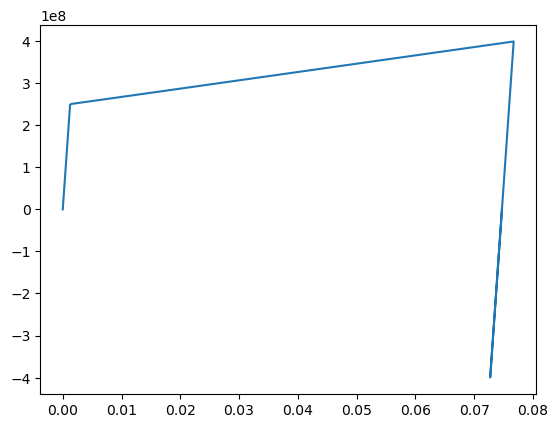

In [84]:
import os
def load_rpt(filename:str,xlabel:str,ylabel:str,):
    """ Load an abaqus .rpt file with ONLY ONE dataset

    Args:
        filename (str): name of the abaqus.rpt file
        xlabel (str): label for the x column
        ylabel (str): label for the y column

    Returns:
        dict: the data, with x-column data labeled as xlabel and y-column data labeled as ylabel
    """
    
    # open rpt file
    filename = os.path.join(filename)
    with open(filename, 'r') as rptfile:
        lines = rptfile.readlines()
        X,Y = [], []
        # skip first 3 lines wit h variable names
        lines = lines[3:]
        
        for i, line in enumerate(lines):
            # Remove whitespace and extract tokens
            line = line.strip().split()
            if len(line) < 2: continue
            X.append(float(line[0]))
            Y.append(float(line[1]))
            
        return {xlabel: X, ylabel: Y}
    
abaqus_3d_builtin = r'D:\OneDrive\Documents\! School\! 24 2024 Spring Semester CU\2 CVEN 6511\Homework\7\7\results\bar_builtin.rpt'
stress = 'Axial Stress (Pa)'
strain = 'Axial Strain'
plane_data_builtin = load_rpt(abaqus_3d_builtin, strain, stress)
plt.plot(plane_data_builtin[strain], plane_data_builtin[stress])

Rtol = 1.000e+00 F_R=7.440e+04 displ=1.860e-04 n = 32 t=6.400e-01 k = 0:  16%|█▌        | 31/200 [00:00<00:01, 106.48it/s]  C:\Users\coast\AppData\Local\Temp\ipykernel_2168\648301179.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  el_isvs[i, 0] = alpha_n + dalpha
C:\Users\coast\AppData\Local\Temp\ipykernel_2168\648301179.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  el_isvs[i, 1] = kappa_n + dkappa
C:\Users\coast\AppData\Local\Temp\ipykernel_2168\648301179.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array befo

(201, 2, 1, 1) (201, 2, 1, 1)


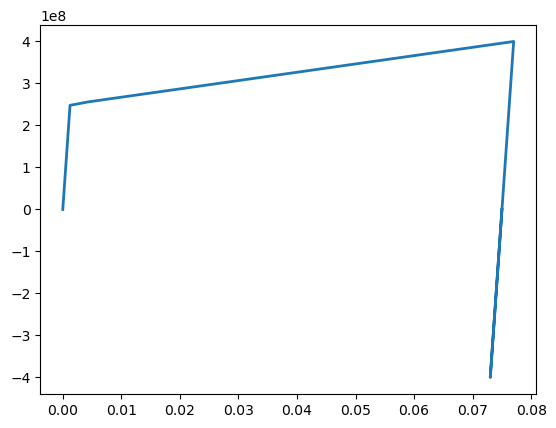

In [114]:
nsteps = 200

Fsteps = [0, 12e4, -12e4, 0]
Fparts = [1, 2, 1]
Nparts = Fparts/np.sum(Fparts)*nsteps
F, NGparts, t_end = ramp_func(Fsteps, Fparts, 'Linear')
F_conc, fixed_bcs = calc_F_conc_vector(F)

Nel=2
E = 2e11
H_kappa = 2e9
H_alpha = 0
alpha0 = 0
kappa0_vec = np.full(Nel, 2.5e8) 
# kappa0_vec[-1] = 9.0e6

A = 3e-4
L = 0.15
f = 25

nisvs = 3
el_isvs  = np.zeros((Nel, nisvs))
el_isvs[:, 0] = alpha0
el_isvs[:, 1] = kappa0_vec

params = (E, H_kappa, H_alpha)

time, ns, displ, el_strain, el_stress, isv, dep, force = FE_code_displ(
    calc_F_conc_vector=F_conc, calc_fixed_bcs=fixed_bcs,nsteps=nsteps, calc_el_stress=calc_el_stress_ep, nisvs=nisvs,
    cons_params=params, el_isvs_0=el_isvs, t_end=t_end,
    Nel=Nel, f=f, maxiter=50, A=A, L=L, atol=1e-8, rtol=1e-10, numips=1, Neldof=2)

plt.figure()
plt.plot(el_strain[:,-1,-1,], el_stress[:,-1,-1],  linewidth=2, label='DISPL FEM solution ',)
# plt.scatter(el_strain[:,-1,-1,], el_stress[:,-1,-1],  marker='o', color='k', s=20)

data = pd.DataFrame({'strain':el_strain[:,-1,0].squeeze(), 'stress':el_stress[:,-1].squeeze()})
data.to_csv('results/p6_1a.csv')

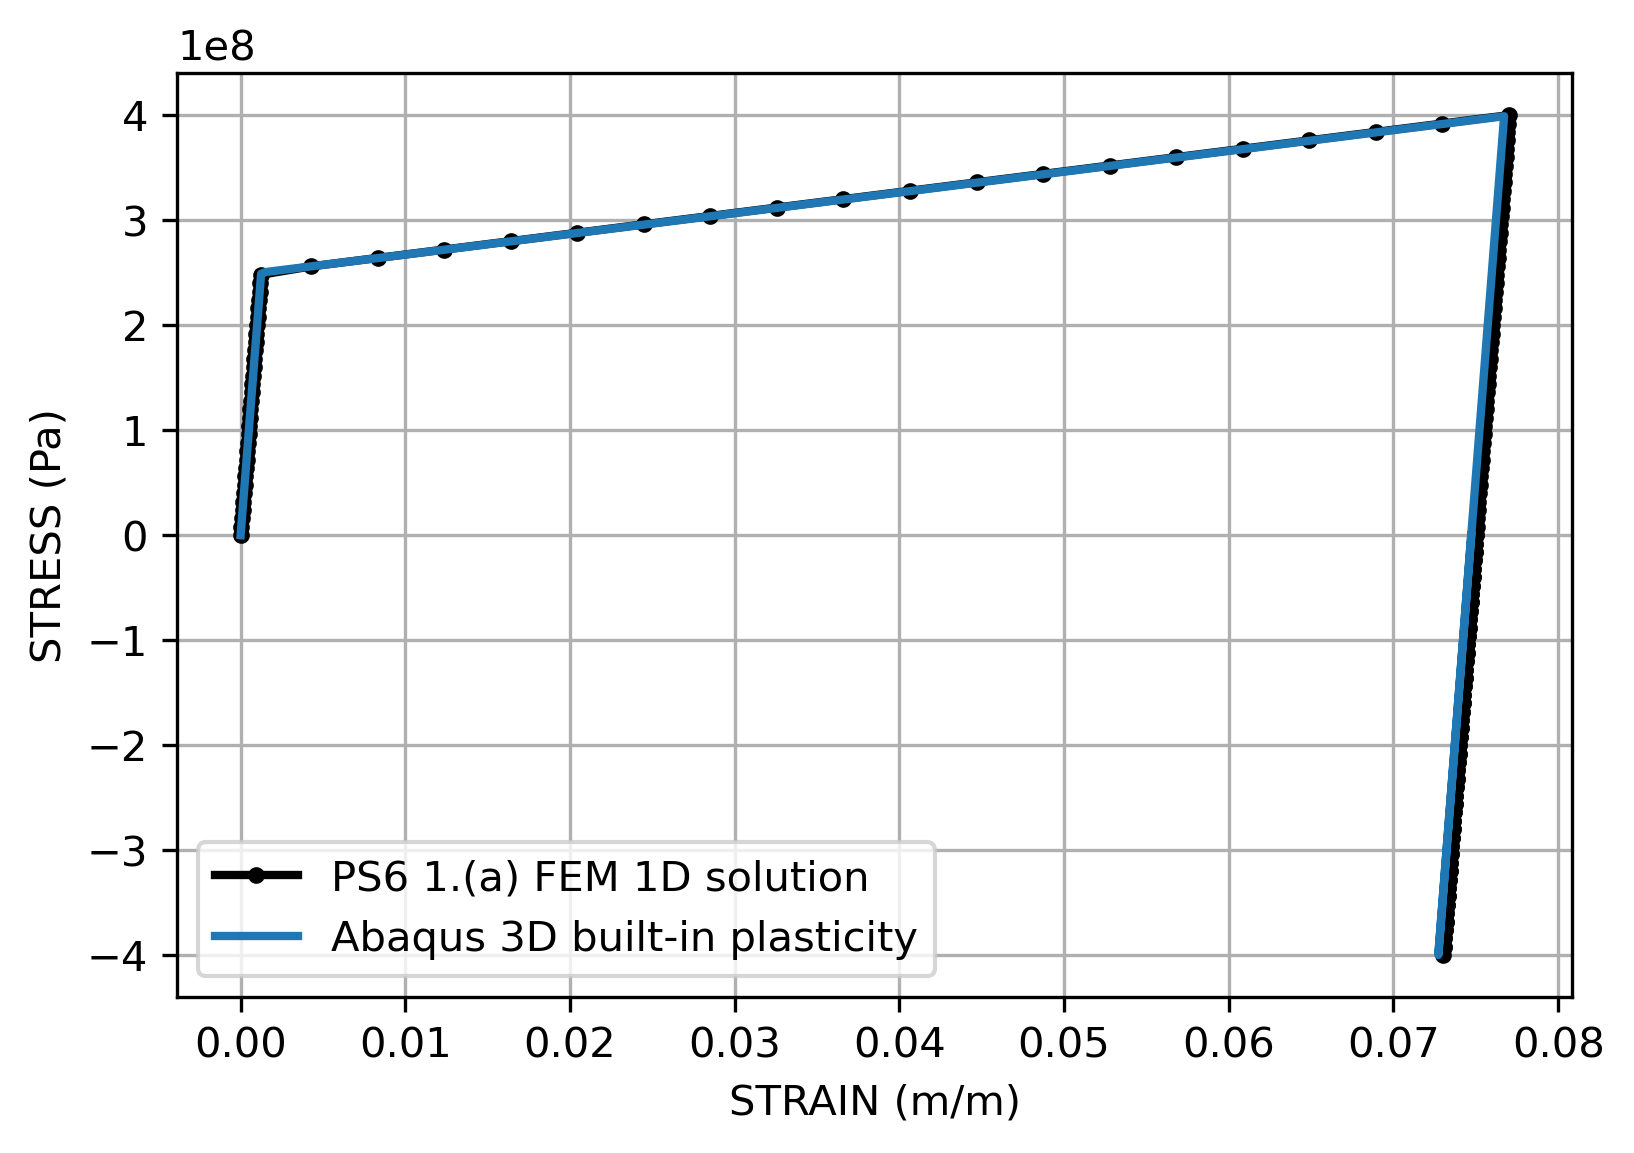

In [87]:
plt.figure(figsize=(6,4), dpi=300)
plt.plot(el_strain[:,-1,-1,], el_stress[:,-1,-1],  '.-', color='k', linewidth=2, label='PS6 1.(a) FEM 1D solution',)
plt.plot(plane_data_builtin[strain], plane_data_builtin[stress], '-', linewidth=2, label='Abaqus 3D built-in plasticity')
plt.legend(loc='lower left')
plt.grid()
plt.xlabel('STRAIN (m/m)')
plt.ylabel('STRESS (Pa)')
plt.savefig('images/p2a_abaqus_vs_ps61a.png')

Rtol = 1.000e+00 F_R=7.488e+04 displ=1.872e-04 n = 209 t=6.270e-01 k = 0:  21%|██        | 208/1000 [00:01<00:07, 101.98it/s]  C:\Users\coast\AppData\Local\Temp\ipykernel_2168\648301179.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  el_isvs[i, 0] = alpha_n + dalpha
C:\Users\coast\AppData\Local\Temp\ipykernel_2168\648301179.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  el_isvs[i, 1] = kappa_n + dkappa
C:\Users\coast\AppData\Local\Temp\ipykernel_2168\648301179.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array b

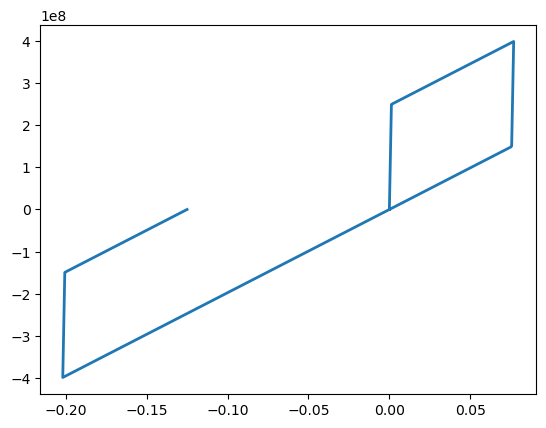

In [115]:
nsteps = 1000

gsteps = [0, -0.25e-3, -0.25e-3]
gparts = [3e1,1e1]
Nparts = gparts/np.sum(gparts)*nsteps
G, NGparts, t_end = ramp_func(gsteps, gparts, 'Linear')


Fsteps = [0, 12e4, -12e4, 0]
Fparts = [1, 1, 1]
Nparts = Fparts/np.sum(Fparts)*nsteps
F, NGparts, t_end = ramp_func(Fsteps, Fparts, 'Linear')
F_conc, fixed_bcs = calc_F_conc_vector(F)

Nel=2
E = 2e11
H_kappa = 0
H_alpha = 2e9
alpha0 = 1.25e8
kappa0_vec = np.zeros(Nel) + 1.25e8 
# kappa0_vec[-1] = 9.0e6

A = 3e-4
L = 0.15
f = 25

nisvs = 3
el_isvs  = np.zeros((Nel, nisvs))
el_isvs[:, 0] = alpha0
el_isvs[:, 1] = kappa0_vec

params = (E, H_kappa, H_alpha)

time, ns, displ, el_strain, el_stress, isv, dep, force = FE_code_displ(
    calc_F_conc_vector=F_conc, calc_fixed_bcs=fixed_bcs,nsteps=nsteps, calc_el_stress=calc_el_stress_ep, nisvs=nisvs,
    cons_params=params, el_isvs_0=el_isvs, t_end=t_end,
    Nel=Nel, f=f, maxiter=50, A=A, L=L, atol=1e-8, rtol=1e-10, numips=1, Neldof=2)

plt.figure()
plt.plot(el_strain[:,-1,-1,], el_stress[:,-1,-1],  linewidth=2, label='DISPL FEM solution ',)

data = pd.DataFrame({'strain':el_strain[:,-1,0].squeeze(), 'stress':el_stress[:,-1].squeeze()})
data.to_csv('results/p6_1b.csv')

t_end, 4


Rtol = 1.000e+00 F_R=7.488e+04 displ=1.872e-04 n = 157 t=6.280e-01 k = 0:  16%|█▌        | 156/1000 [00:01<00:06, 136.25it/s]  C:\Users\coast\AppData\Local\Temp\ipykernel_2168\648301179.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  el_isvs[i, 0] = alpha_n + dalpha
C:\Users\coast\AppData\Local\Temp\ipykernel_2168\648301179.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  el_isvs[i, 1] = kappa_n + dkappa
C:\Users\coast\AppData\Local\Temp\ipykernel_2168\648301179.py:52: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array b

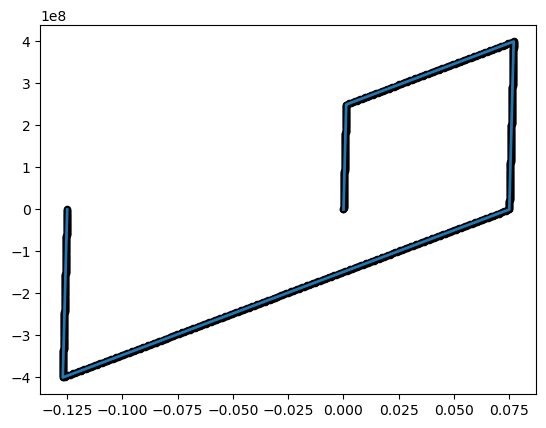

In [116]:
nsteps = 1000

gsteps = [0, -0.25e-3, -0.25e-3]
gparts = [3e1,1e1]
Nparts = gparts/np.sum(gparts)*nsteps
G, NGparts, t_end = ramp_func(gsteps, gparts, 'Linear')

Fsteps = [0, 12e4, -12e4, 0]
Fparts = [1, 2, 1]
Nparts = Fparts/np.sum(Fparts)*nsteps
F, NGparts, t_end = ramp_func(Fsteps, Fparts, 'Linear')
F_conc, fixed_bcs = calc_F_conc_vector(F)
print('t_end,', t_end)

Nel=2
E = 2e11
H_kappa = 1e9
H_alpha = 1e9
alpha0 = 1.25e8
kappa0_vec = np.zeros(Nel) + 1.25e8 
# kappa0_vec[-1] = 9.0e6

A = 3e-4
L = 0.15
f = 25

nisvs = 3
el_isvs  = np.zeros((Nel, nisvs))
el_isvs[:, 0] = alpha0
el_isvs[:, 1] = kappa0_vec

params = (E, H_kappa, H_alpha)

time, ns, displ, el_strain, el_stress, isv, dep, force = FE_code_displ(
    calc_F_conc_vector=F_conc, calc_fixed_bcs=fixed_bcs,nsteps=nsteps, calc_el_stress=calc_el_stress_ep, nisvs=nisvs,
    cons_params=params, el_isvs_0=el_isvs, t_end=t_end,
    Nel=Nel, f=f, maxiter=50, A=A, L=L, atol=1e-8, rtol=1e-10, numips=1, Neldof=2)

plt.figure()
plt.plot(el_strain[:,-1,-1,], el_stress[:,-1,-1],  linewidth=2, label='DISPL FEM solution ',)
plt.scatter(el_strain[:,-1,-1,], el_stress[:,-1,-1],  marker='o', color='k', s=20)

data = pd.DataFrame({'strain':el_strain[:,-1,0].squeeze(), 'stress':el_stress[:,-1].squeeze()})
data.to_csv('results/p6_1c.csv')